
[../ClinVar_TCGA_1000G_resources/Clinvar_variant_RBP_by_disease_top10.pdf] Top 10 diseases used for plotting:
   Hereditary_breast_ovarian_cancer
   Lynch_syndrome
   Neurofibromatosis,_type_1
   Hereditary_nonpolyposis_colorectal_neoplasms
   Phenylketonuria
   Tuberous_sclerosis_syndrome
   Hypercholesterolemia,_familial,_1
   RASopathy
   Developmental_and_epileptic_encephalopathy
   Charcot-Marie-Tooth_disease


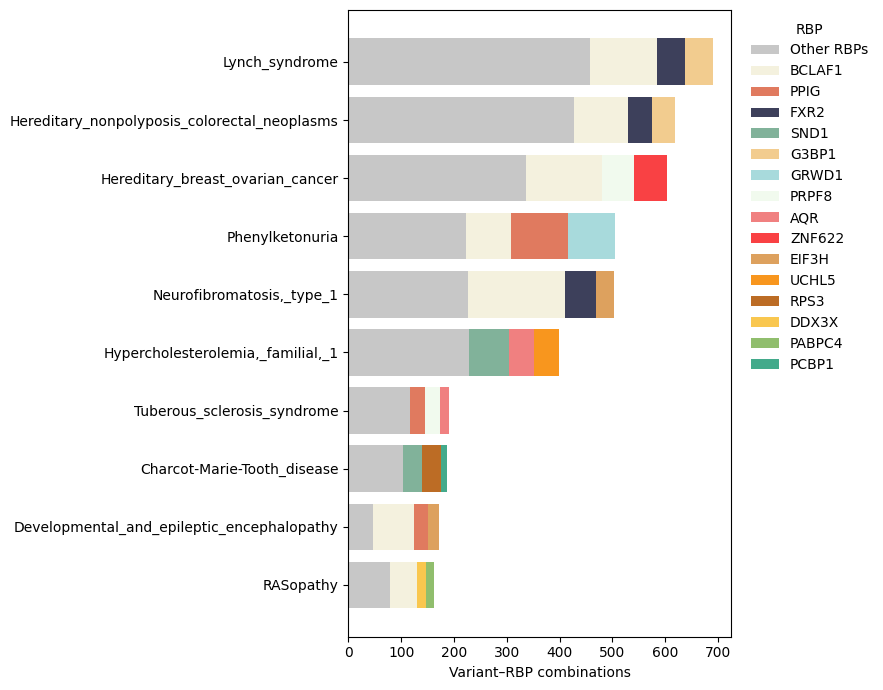


[../ClinVar_TCGA_1000G_resources/1000G_variant_RBP_by_disease_top10.pdf] Top 10 diseases used for plotting:
   Hereditary_cancer-predisposing_syndrome
   Hereditary_nonpolyposis_colorectal_neoplasms
   Lynch_syndrome
   Familial_cancer_of_breast
   Ataxia-telangiectasia_syndrome
   Familial_hypercholesterolemia
   Neurofibromatosis,_type_1
   Hereditary_breast_ovarian_cancer_syndrome
   Phenylketonuria
   Developmental_and_epileptic_encephalopathy


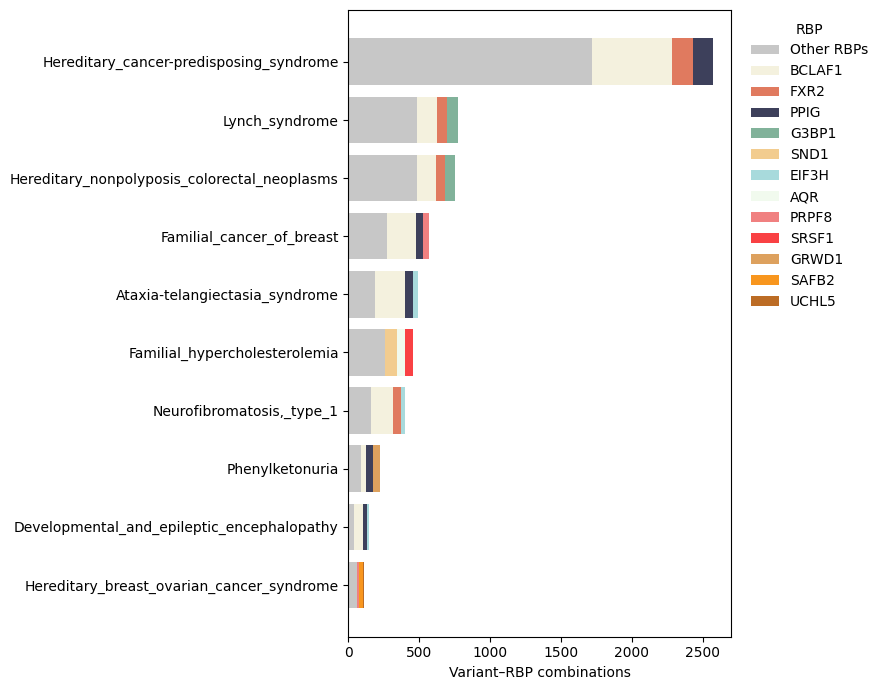

/tmp/ipykernel_1378760/988245340.py:222: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv, header=None)



[../ClinVar_TCGA_1000G_resources/TCGA_variant_RBP_by_cancer_top10.pdf] Top 10 cancers used for plotting:
   UCEC
   COAD
   SKCM
   STAD
   LUAD
   LUSC
   BLCA
   BRCA
   HNSC
   CESC


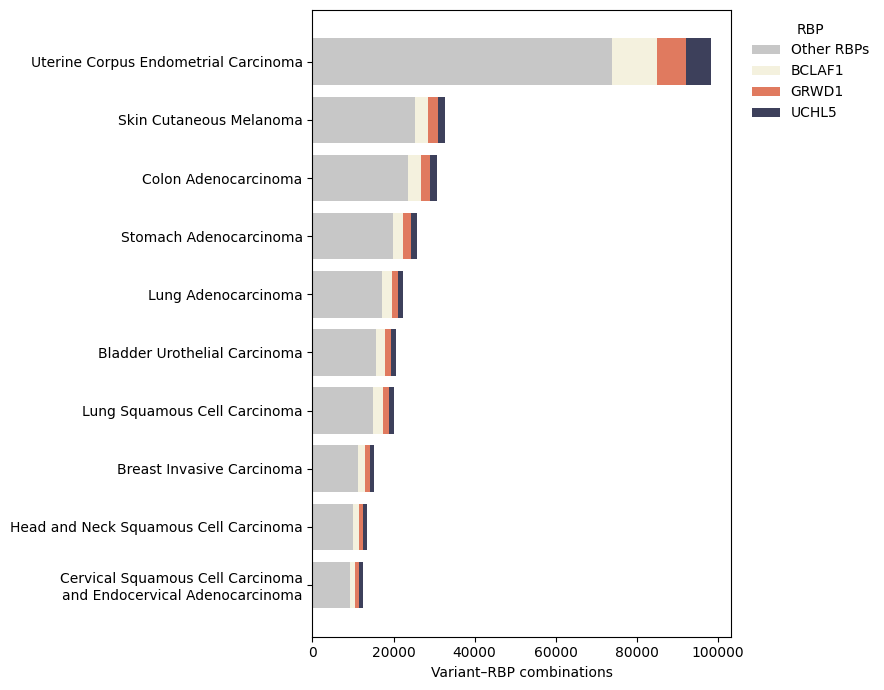

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


# ===============================
# Shared helpers
# ===============================
PALETTE = [
    "#f4f1de", "#e07a5f", "#3d405b", "#81b29a", "#f2cc8f", "#a8dadc", "#f1faee", "#f08080",
    "#F94144", "#dda15e", "#F8961E", "#bc6c25", "#F9C74F", "#90BE6D", "#43AA8B",
    "#4D908E", "#577590", "#277DA1", "#AEC7E8", "#FFBB78", "#98DF8A", "#FF9896",
    "#C5B0D5", "#C49C94", "#F7B6D2", "#C7C7C7",
]


def _build_color_map(columns, palette=PALETTE, other_label="Other RBPs", other_color="#C7C7C7"):
    """Assign colors to each stacked category, keeping 'Other RBPs' in gray."""
    colors = {}
    color_idx = 0
    for col in columns:
        if col == other_label:
            colors[col] = other_color
        else:
            colors[col] = palette[color_idx % len(palette)]
            color_idx += 1
    return colors


def _plot_stacked_barh(
    pivot_df,
    xlabel,
    output_pdf=None,
    figsize=(9, 7),
    legend_title="RBP",
    show=True,
):
    """Plot a horizontal stacked bar chart from a pivot table."""
    fig, ax = plt.subplots(figsize=figsize)

    left = None
    colors = _build_color_map(pivot_df.columns)

    for col in pivot_df.columns:
        ax.barh(
            pivot_df.index,
            pivot_df[col],
            left=left,
            color=colors[col],
            label=col,
        )
        left = pivot_df[col] if left is None else left + pivot_df[col]

    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.invert_yaxis()

    # Leave a small margin on the right side of the x-axis
    xmax = pivot_df.sum(axis=1).max()
    ax.set_xlim(right=xmax * 1.05)

    ax.legend(
        title=legend_title,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False,
    )

    plt.tight_layout()

    if output_pdf is not None:
        plt.savefig(output_pdf, format="pdf")

    if show:
        plt.show()

    plt.close()


def _keep_topk_per_group(count_df, group_col, value_col, top_k=3, other_label="Other RBPs"):
    """Within each group, keep top-K categories and aggregate the rest as 'Other RBPs'."""
    def mark_topk(group):
        topk = (
            group.sort_values(value_col, ascending=False)
            .head(top_k)["RBP"]
            .tolist()
        )
        group["RBP_group"] = group["RBP"].apply(lambda x: x if x in topk else other_label)
        return group

    plot_df = (
        count_df
        .groupby(group_col, group_keys=False)
        .apply(mark_topk)
        .groupby([group_col, "RBP_group"])[value_col]
        .sum()
        .reset_index()
    )
    return plot_df


# ===============================
# Dataset-specific processing
# ===============================
def process_disease_dataset(
    input_csv,
    output_pdf,
    exclude_diseases,
    disease_merge_map,
    top_n=10,
    top_k_rbps=3,
    show=True,
):
    """ClinVar/1000G: plot top diseases by Variant–RBP combinations."""

    def normalize_disease(d):
        if d in exclude_diseases:
            return None
        return disease_merge_map.get(d, d)

    # Read input
    df = pd.read_csv(input_csv)

    # Compute disease frequencies (after normalization) and select top-N
    all_diseases = (
        df["ClinVar_CLNDN"]
        .dropna()
        .astype(str)
        .str.split("|")
        .explode()
        .map(normalize_disease)
        .dropna()
        .value_counts()
    )
    top_diseases = all_diseases.head(top_n).index.tolist()

    print(f"\n[{output_pdf}] Top {top_n} diseases used for plotting:")
    for d in top_diseases:
        print("  ", d)

    # Build variant–RBP–disease triplets
    records = []
    for _, row in df.iterrows():
        variant_id = f"{row['CHROM']}:{row['POS']}:{row['REF']}>{row['ALT']}"

        # Remove cell line suffixes (e.g., 'AATF_K562' -> 'AATF')
        rbp_list = row.get("RBP_list", "")
        if pd.isna(rbp_list):
            rbps = []
        else:
            rbps = [r.split("_")[0] for r in str(rbp_list).split(",") if r]

        diseases = str(row.get("ClinVar_CLNDN", "")).split("|")

        for d in diseases:
            d_norm = normalize_disease(d)
            if d_norm is None or d_norm not in top_diseases:
                continue
            for r in rbps:
                records.append({"variant": variant_id, "RBP": r, "disease": d_norm})

    tri_df = pd.DataFrame(records)
    if tri_df.empty:
        raise ValueError(f"No records found after filtering for: {input_csv}")

    # Count unique Variant–RBP pairs per disease
    count_df = (
        tri_df.drop_duplicates()
        .groupby(["disease", "RBP"])
        .size()
        .reset_index(name="n_variant_rbp")
    )

    # Keep top-K RBPs per disease, aggregate the rest
    plot_df = _keep_topk_per_group(
        count_df=count_df,
        group_col="disease",
        value_col="n_variant_rbp",
        top_k=top_k_rbps,
    )

    # Order diseases by total counts
    disease_order = (
        plot_df.groupby("disease")["n_variant_rbp"]
        .sum()
        .sort_values(ascending=False)
        .index
    )

    # Order RBPs globally by total counts (not alphabetically)
    rbp_order = (
        plot_df.groupby("RBP_group")["n_variant_rbp"]
        .sum()
        .sort_values(ascending=False)
        .index
    )

    pivot_df = (
        plot_df.pivot(index="disease", columns="RBP_group", values="n_variant_rbp")
        .fillna(0)
        .loc[disease_order, rbp_order]
    )

    _plot_stacked_barh(
        pivot_df=pivot_df,
        xlabel="Variant–RBP combinations",
        output_pdf=output_pdf,
        show=show,
    )


def process_tcga_dataset(
    input_csv,
    output_pdf,
    cancer_fullname,
    top_n=10,
    top_k_rbps=3,
    show=True,
):
    """TCGA: plot top cancers by Variant–RBP combinations."""

    # Read input (no header in the original file)
    df = pd.read_csv(input_csv, header=None)
    df.columns = [
        "CHROM", "POS", "POS2", "REF", "ALT",
        "ClinSig", "strand", "cancer",
        "strand2", "RBP",
        "wild_cov", "mut_cov", "gene",
    ]

    # Select top-N cancers by frequency
    cancer_counts = df["cancer"].value_counts()
    top_cancers = cancer_counts.head(top_n).index.tolist()

    print(f"\n[{output_pdf}] Top {top_n} cancers used for plotting:")
    for c in top_cancers:
        print("  ", c)

    # Build variant–RBP–cancer triplets
    records = []
    for _, row in df.iterrows():
        if row["cancer"] not in top_cancers:
            continue

        variant_id = f"{row['CHROM']}:{row['POS']}:{row['REF']}>{row['ALT']}"
        cancer_abbr = row["cancer"]
        cancer_label = cancer_fullname.get(cancer_abbr, cancer_abbr)

        records.append({
            "variant": variant_id,
            "RBP": str(row["RBP"]).split("_")[0],  # remove HepG2/K562 suffix
            "cancer": cancer_label,
        })

    tri_df = pd.DataFrame(records)
    if tri_df.empty:
        raise ValueError(f"No records found after filtering for: {input_csv}")

    # Count unique Variant–RBP pairs per cancer
    count_df = (
        tri_df.drop_duplicates()
        .groupby(["cancer", "RBP"])
        .size()
        .reset_index(name="n_variant_rbp")
    )

    # Keep top-K RBPs per cancer, aggregate the rest
    plot_df = _keep_topk_per_group(
        count_df=count_df,
        group_col="cancer",
        value_col="n_variant_rbp",
        top_k=top_k_rbps,
    )

    # Order cancers by total counts
    cancer_order = (
        plot_df.groupby("cancer")["n_variant_rbp"]
        .sum()
        .sort_values(ascending=False)
        .index
    )

    # Order RBPs globally by total counts
    rbp_order = (
        plot_df.groupby("RBP_group")["n_variant_rbp"]
        .sum()
        .sort_values(ascending=False)
        .index
    )

    pivot_df = (
        plot_df.pivot(index="cancer", columns="RBP_group", values="n_variant_rbp")
        .fillna(0)
        .loc[cancer_order, rbp_order]
    )

    _plot_stacked_barh(
        pivot_df=pivot_df,
        xlabel="Variant–RBP combinations",
        output_pdf=output_pdf,
        show=show,
    )


# ===============================
# Run all three analyses with one for-loop
# ===============================
CONFIGS = [
    {
        "type": "disease",
        "input_csv": "../ClinVar_TCGA_1000G_resources/clinvar_diff.variant_with_rbp.csv",
        "output_pdf": "../ClinVar_TCGA_1000G_resources/Clinvar_variant_RBP_by_disease_top10.pdf",
        "exclude_diseases": {
            "not_provided",
            "not_specified",
            "Hereditary_cancer-predisposing_syndrome",
            "Inborn_genetic_diseases",
            "Cardiovascular_phenotype",
            "Ataxia-telangiectasia_syndrome",
        },
        "disease_merge_map": {
            "Breast-ovarian_cancer,_familial,_susceptibility_to,_1": "Hereditary_breast_ovarian_cancer",
            "Familial_cancer_of_breast": "Hereditary_breast_ovarian_cancer",
            "Hereditary_breast_ovarian_cancer_syndrome": "Hereditary_breast_ovarian_cancer",
            "Lynch_syndrome_5": "Lynch_syndrome",
            "Lynch_syndrome_1": "Lynch_syndrome",
            "Tuberous_sclerosis_2": "Tuberous_sclerosis_syndrome",
        },
        "show": True,
    },
    {
        "type": "disease",
        "input_csv": "../ClinVar_TCGA_1000G_resources/1000genomes_diff.variant_with_rbp.csv",
        "output_pdf": "../ClinVar_TCGA_1000G_resources/1000G_variant_RBP_by_disease_top10.pdf",
        "exclude_diseases": {
            "-",
            "not_provided",
            "not_specified",
            "Cardiovascular_phenotype",
            "Inborn_genetic_diseases",
        },
        "disease_merge_map": {
            "Colorectal_cancer,_hereditary_nonpolyposis,_type_2": "Hereditary_nonpolyposis_colorectal_neoplasms",
            "Hypercholesterolemia,_familial,_1": "Familial_hypercholesterolemia",
            "Lynch_syndrome_5": "Lynch_syndrome",
            "Lynch_syndrome_1": "Lynch_syndrome",
        },
        "show": True,
    },
    {
        "type": "tcga",
        "input_csv": "../ClinVar_TCGA_1000G_resources/tcga_diff.all.csv",
        "output_pdf": "../ClinVar_TCGA_1000G_resources/TCGA_variant_RBP_by_cancer_top10.pdf",
        "cancer_fullname": {
            "UCEC": "Uterine Corpus Endometrial Carcinoma",
            "SKCM": "Skin Cutaneous Melanoma",
            "COAD": "Colon Adenocarcinoma",
            "STAD": "Stomach Adenocarcinoma",
            "LUAD": "Lung Adenocarcinoma",
            "BLCA": "Bladder Urothelial Carcinoma",
            "LUSC": "Lung Squamous Cell Carcinoma",
            "BRCA": "Breast Invasive Carcinoma",
            "HNSC": "Head and Neck Squamous Cell Carcinoma",
            "CESC": "Cervical Squamous Cell Carcinoma\nand Endocervical Adenocarcinoma",
        },
        "show": True,
    },
]

for cfg in CONFIGS:
    if cfg["type"] == "disease":
        process_disease_dataset(
            input_csv=cfg["input_csv"],
            output_pdf=cfg["output_pdf"],
            exclude_diseases=cfg["exclude_diseases"],
            disease_merge_map=cfg["disease_merge_map"],
            show=cfg.get("show", True),
        )
    elif cfg["type"] == "tcga":
        process_tcga_dataset(
            input_csv=cfg["input_csv"],
            output_pdf=cfg["output_pdf"],
            cancer_fullname=cfg["cancer_fullname"],
            show=cfg.get("show", True),
        )
    else:
        raise ValueError(f"Unknown config type: {cfg['type']}")
